# GSoC 2026 — ML4SCI E2E Task 2b: Super Resolution at the CMS Detector

**Author:** Yuxi (Joey) Yang — Johns Hopkins University  
**Project:** End-to-End Deep Learning / CMS  
**Task:** Train a GAN for super-resolution on particle collision calorimeter images  

---

## Overview

This notebook implements an **ESRGAN (Enhanced Super-Resolution GAN)** to upsample low-resolution (64×64) particle collision calorimeter images to high-resolution (125×125). The dataset consists of 3-channel images representing energy deposits from quarks and gluons impinging on a CMS calorimeter.

### Model Selection Rationale

I chose **ESRGAN** over other SR architectures for the following reasons:
- **RRDB blocks** (Residual-in-Residual Dense Blocks) provide deeper feature extraction without Batch Normalization, leading to more stable training and fewer artifacts.
- **Multi-component loss** (pixel + perceptual + adversarial) balances reconstruction accuracy with high-frequency detail recovery.
- ESRGAN is a well-established baseline in the SR literature, making results interpretable and reproducible.

### Note on Physics Data
Unlike natural images, particle collision data has physical meaning — pixel intensities correspond to energy deposits. Therefore, **pixel-level fidelity** (PSNR, SSIM) matters as much or more than perceptual quality, and we should verify that the total energy is conserved after super-resolution.

### Dataset
- **LR images**: 3 × 64 × 64 (low-granularity calorimeter)
- **HR images**: 3 × 125 × 125 (high-granularity calorimeter)
- **Scale factor**: ~1.95× (not an integer ratio)
- **Labels**: 0 = quark, 1 = gluon
- **Format**: Parquet files with columns `X_jets_LR`, `X_jets`, `pt`, `m0`, `y`

## 1. Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import models
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pyarrow.parquet as pq
import os
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Loading

The dataset is ~3.7 GB across 3 parquet files (~139K total samples). To avoid OOM, we load data in batches using PyArrow and only keep a manageable subset in memory.

In [4]:
DATA_DIR = '/content/drive/MyDrive/task2b dataset/'
PARQUET_FILES = sorted([os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.parquet')])
print(f'Found {len(PARQUET_FILES)} parquet files:')
for f in PARQUET_FILES:
    print(f'  {os.path.basename(f)} ({os.path.getsize(f)/1e6:.0f} MB)')

Found 3 parquet files:
  QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet (964 MB)
  QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet (1262 MB)
  QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet (1499 MB)


In [5]:
# ============================================================
# Load a subset of data to fit in Colab RAM
# We'll use the first file (~36K samples) for training
# and a portion of the second file for validation/test.
# ============================================================
def load_parquet_data(filepath, max_samples=None):
    """Load LR, HR images and labels from a parquet file."""
    pf = pq.ParquetFile(filepath)

    lr_list = []
    hr_list = []
    y_list = []
    count = 0

    for batch in pf.iter_batches(batch_size=500, columns=['X_jets_LR', 'X_jets', 'y']):
        for i in range(batch.num_rows):
            lr_list.append(np.array(batch.column('X_jets_LR')[i].as_py(), dtype=np.float32))
            hr_list.append(np.array(batch.column('X_jets')[i].as_py(), dtype=np.float32))
            y_list.append(batch.column('y')[i].as_py())
            count += 1
            if max_samples and count >= max_samples:
                break
        if max_samples and count >= max_samples:
            break
        if count % 5000 == 0:
            print(f'  Loaded {count} samples...')

    return np.stack(lr_list), np.stack(hr_list), np.array(y_list)

# Load data — adjust max_samples based on available RAM
# Colab free: ~20K samples is safe
# Colab Pro: can do more
MAX_SAMPLES = 10000

print(f'Loading up to {MAX_SAMPLES} samples from first file...')
X_LR, X_HR, y = load_parquet_data(PARQUET_FILES[0], max_samples=MAX_SAMPLES)

print(f'\nLoaded:')
print(f'  LR: {X_LR.shape} — range: [{X_LR.min():.4f}, {X_LR.max():.4f}]')
print(f'  HR: {X_HR.shape} — range: [{X_HR.min():.4f}, {X_HR.max():.4f}]')
print(f'  Labels: {y.shape} — quarks: {(y==0).sum()}, gluons: {(y==1).sum()}')

Loading up to 10000 samples from first file...
  Loaded 5000 samples...

Loaded:
  LR: (10000, 3, 64, 64) — range: [-4.1464, 2123.3191]
  HR: (10000, 3, 125, 125) — range: [-10.5442, 8477.8428]
  Labels: (10000,) — quarks: 4962, gluons: 5038


In [6]:
print(f'X_HR shape: {X_HR.shape}')
print(f'X_LR shape: {X_LR.shape}')

X_HR shape: (10000, 3, 125, 125)
X_LR shape: (10000, 3, 64, 64)


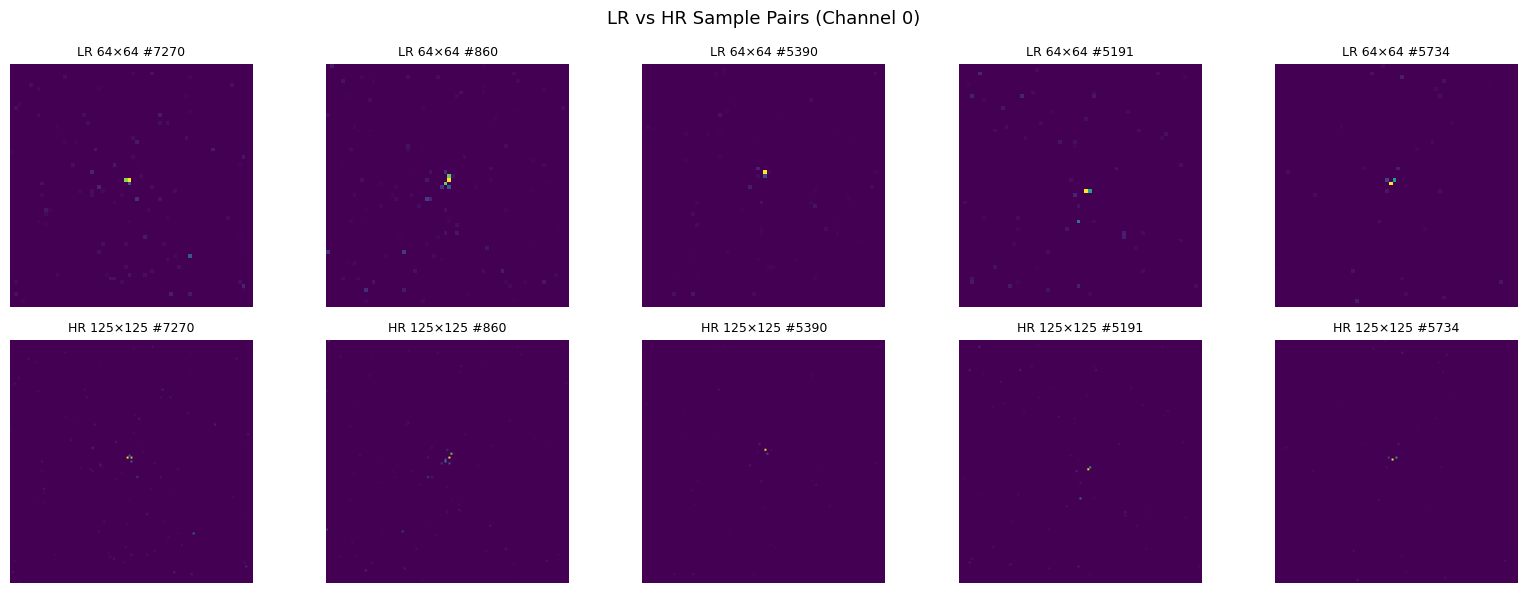

In [7]:
# ============================================================
# Visualize LR vs HR pairs
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
np.random.seed(42)
for i in range(5):
    idx = np.random.randint(len(X_HR))

    lr_vis = X_LR[idx, 0]  # Channel 0
    hr_vis = X_HR[idx, 0]

    axes[0, i].imshow(lr_vis, cmap='viridis')
    axes[0, i].set_title(f'LR 64×64 #{idx}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(hr_vis, cmap='viridis')
    axes[1, i].set_title(f'HR 125×125 #{idx}', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Low Res (64×64)', fontsize=11)
axes[1, 0].set_ylabel('High Res (125×125)', fontsize=11)
plt.suptitle('LR vs HR Sample Pairs (Channel 0)', fontsize=13)
plt.tight_layout()
plt.savefig('lr_hr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Mean total energy — LR: 61.28, HR: 245.12
Energy ratio (HR/LR): 4.0000


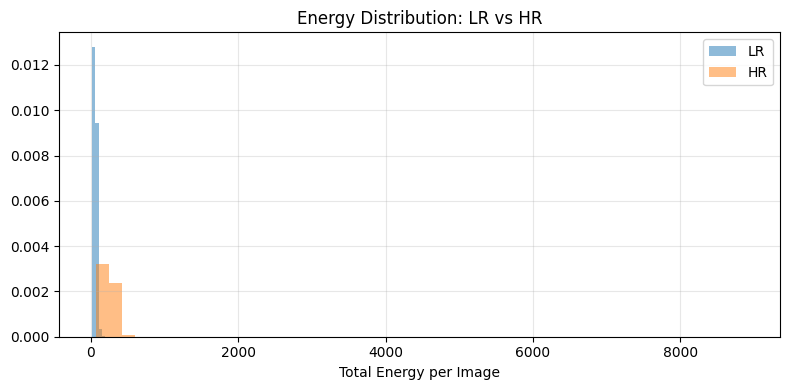

In [8]:
# ============================================================
# Energy distribution analysis
# ============================================================
lr_energy = X_LR.sum(axis=(1, 2, 3))
hr_energy = X_HR.sum(axis=(1, 2, 3))

print(f'Mean total energy — LR: {lr_energy.mean():.2f}, HR: {hr_energy.mean():.2f}')
print(f'Energy ratio (HR/LR): {(hr_energy / (lr_energy + 1e-8)).mean():.4f}')

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(lr_energy, bins=50, alpha=0.5, label='LR', density=True)
ax.hist(hr_energy, bins=50, alpha=0.5, label='HR', density=True)
ax.set_xlabel('Total Energy per Image')
ax.set_title('Energy Distribution: LR vs HR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing and DataLoader

In [9]:
# ============================================================
# Normalization
# The data has negative values and is not normalized.
# We use global max normalization to preserve relative scale.
# ============================================================
import numpy as np

global_max = max(np.abs(X_HR).max(), np.abs(X_LR).max())
X_HR_norm = X_HR / global_max
X_LR_norm = X_LR / global_max

print(f'Global max: {global_max:.4f}')
print(f'After norm — LR: [{X_LR_norm.min():.4f}, {X_LR_norm.max():.4f}]')
print(f'After norm — HR: [{X_HR_norm.min():.4f}, {X_HR_norm.max():.4f}]')

GLOBAL_MAX = global_max

Global max: 8477.8428
After norm — LR: [-0.0005, 0.2505]
After norm — HR: [-0.0012, 1.0000]


In [10]:
# ============================================================
# Train / Val / Test split (80 / 10 / 10)
# ============================================================
n = len(X_HR_norm)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

print(f'Split: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}')

Split: train=8000, val=1000, test=1000


In [11]:
# ============================================================
# PyTorch Dataset
# ============================================================
class JetSRDataset(Dataset):
    def __init__(self, lr, hr):
        self.lr = torch.from_numpy(lr)
        self.hr = torch.from_numpy(hr)

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, idx):
        return self.lr[idx], self.hr[idx]

BATCH_SIZE = 16

train_ds = JetSRDataset(X_LR_norm[train_idx], X_HR_norm[train_idx])
val_ds = JetSRDataset(X_LR_norm[val_idx], X_HR_norm[val_idx])
test_ds = JetSRDataset(X_LR_norm[test_idx], X_HR_norm[test_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Free raw arrays to save RAM
del X_LR, X_HR
import gc; gc.collect()

print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Train batches: 500, Val: 63, Test: 63


## 4. Model Architecture — ESRGAN

Key design choices for 64×64 → 125×125 upsampling:
- Use PixelShuffle for 2× upsample (64→128)
- Then use learned interpolation to crop/resize 128→125
- No Batch Normalization in generator (following ESRGAN design)

In [12]:
# ============================================================
# Residual Dense Block (RDB)
# ============================================================
class ResidualDenseBlock(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.beta = 0.2

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], 1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], 1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], 1))
        return x5 * self.beta + x


class RRDB(nn.Module):
    """Residual in Residual Dense Block."""
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(nf, gc)
        self.rdb2 = ResidualDenseBlock(nf, gc)
        self.rdb3 = ResidualDenseBlock(nf, gc)
        self.beta = 0.2

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * self.beta + x

In [13]:
# ============================================================
# Generator: 64×64 → 125×125
# Strategy: PixelShuffle 2× (64→128), then adaptive output to 125
# ============================================================
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, nf=64, nb=6, gc=32):
        super().__init__()
        self.conv_first = nn.Conv2d(in_channels, nf, 3, 1, 1)
        self.rrdb_trunk = nn.Sequential(*[RRDB(nf, gc) for _ in range(nb)])
        self.trunk_conv = nn.Conv2d(nf, nf, 3, 1, 1)

        # 2× upsample: 64 → 128
        self.upsample = nn.Sequential(
            nn.Conv2d(nf, nf * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, True),
        )

        # Final conv layers
        self.conv_hr = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_last = nn.Conv2d(nf, out_channels, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

        self.target_size = 125

    def forward(self, x):
        feat = self.conv_first(x)                   # (B, 64, 64, 64)
        trunk = self.trunk_conv(self.rrdb_trunk(feat))
        feat = feat + trunk                          # Global residual
        feat = self.upsample(feat)                   # (B, 64, 128, 128)
        out = self.conv_last(self.lrelu(self.conv_hr(feat)))  # (B, 3, 128, 128)
        # Resize 128 → 125 using bilinear interpolation
        out = F.interpolate(out, size=self.target_size, mode='bilinear', align_corners=False)
        return out


# ============================================================
# Discriminator (VGG-style)
# ============================================================
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        def conv_block(in_c, out_c, stride=1, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 3, stride, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, True))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(in_channels, 64, 1, bn=False),
            conv_block(64, 64, 2),
            conv_block(64, 128, 1),
            conv_block(128, 128, 2),
            conv_block(128, 256, 1),
            conv_block(256, 256, 2),
            conv_block(256, 512, 1),
            conv_block(512, 512, 2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, True),
            nn.Linear(1024, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [14]:
# ============================================================
# Instantiate and verify
# ============================================================
generator = Generator(in_channels=3, out_channels=3, nf=64, nb=6, gc=32).to(device)
discriminator = Discriminator(in_channels=3).to(device)

# Verify shapes
with torch.no_grad():
    test_lr = torch.randn(1, 3, 64, 64).to(device)
    test_sr = generator(test_lr)
    test_d = discriminator(test_sr)
    print(f'Input:  {test_lr.shape}')
    print(f'Output: {test_sr.shape}  ← should be (1, 3, 125, 125)')
    print(f'D out:  {test_d.shape}')

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f'\nGenerator params:     {g_params:,}')
print(f'Discriminator params: {d_params:,}')

Input:  torch.Size([1, 3, 64, 64])
Output: torch.Size([1, 3, 125, 125])  ← should be (1, 3, 125, 125)
D out:  torch.Size([1, 1])

Generator params:     4,541,635
Discriminator params: 5,215,425


## 5. Loss Functions

In [15]:
# ============================================================
# Perceptual Loss (VGG19 features)
# Note: VGG was trained on natural images. We use early layers
# (conv3_4) which capture more generic structural patterns.
# ============================================================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(vgg.features[:16])).eval()
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        # VGG expects 3 channels — our data already has 3 channels
        return F.l1_loss(self.feature_extractor(sr), self.feature_extractor(hr))


criterion_pixel = nn.L1Loss()
criterion_perceptual = VGGPerceptualLoss().to(device)
criterion_adversarial = nn.BCEWithLogitsLoss()

# Loss weights — pixel loss dominant for physics data
LAMBDA_PIXEL = 1.0
LAMBDA_PERCEPTUAL = 0.006
LAMBDA_ADVERSARIAL = 0.001

print('Loss functions initialized.')
print(f'Weights — Pixel: {LAMBDA_PIXEL}, Perceptual: {LAMBDA_PERCEPTUAL}, Adversarial: {LAMBDA_ADVERSARIAL}')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 191MB/s]


Loss functions initialized.
Weights — Pixel: 1.0, Perceptual: 0.006, Adversarial: 0.001


## 6. Training

In [16]:
# ============================================================
# Optimizers and schedulers
# ============================================================
LR_G = 1e-4
LR_D = 1e-4

optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(0.9, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.9, 0.999))
scheduler_G = optim.lr_scheduler.StepLR(optimizer_G, step_size=20, gamma=0.5)
scheduler_D = optim.lr_scheduler.StepLR(optimizer_D, step_size=20, gamma=0.5)

In [17]:
# ============================================================
# Phase 1: Pre-train Generator with L1 loss only (PSNR-oriented)
# This stabilizes GAN training significantly.
# ============================================================
PRETRAIN_EPOCHS = 10

print('=== Phase 1: Pre-training Generator (L1 only) ===')
generator.train()
for epoch in range(PRETRAIN_EPOCHS):
    epoch_loss = 0
    for lr_imgs, hr_imgs in train_loader:
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)

        sr_imgs = generator(lr_imgs)
        loss = criterion_pixel(sr_imgs, hr_imgs)

        optimizer_G.zero_grad()
        loss.backward()
        optimizer_G.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f'  Epoch [{epoch+1}/{PRETRAIN_EPOCHS}] — L1 Loss: {avg:.6f}')

print('Pre-training complete.\n')
# ============================================================
# Phase 2: GAN Training
# ============================================================
NUM_EPOCHS = 40
history = {'g_loss': [], 'd_loss': [], 'val_psnr': [], 'val_ssim': []}

print('=== Phase 2: GAN Training ===')
for epoch in range(NUM_EPOCHS):
    generator.train()
    discriminator.train()
    g_loss_epoch = 0
    d_loss_epoch = 0

    for lr_imgs, hr_imgs in train_loader:
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)
        bs = lr_imgs.size(0)
        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # --- Train Discriminator ---
        sr_imgs = generator(lr_imgs).detach()
        pred_real = discriminator(hr_imgs)
        pred_fake = discriminator(sr_imgs)
        d_loss_real = criterion_adversarial(pred_real - pred_fake.mean(0, keepdim=True), real_labels)
        d_loss_fake = criterion_adversarial(pred_fake - pred_real.mean(0, keepdim=True), fake_labels)
        d_loss = (d_loss_real + d_loss_fake) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # --- Train Generator ---
        sr_imgs = generator(lr_imgs)
        pred_real = discriminator(hr_imgs).detach()
        pred_fake = discriminator(sr_imgs)

        loss_pixel = criterion_pixel(sr_imgs, hr_imgs)
        loss_perceptual = criterion_perceptual(sr_imgs, hr_imgs)
        loss_adv = criterion_adversarial(pred_fake - pred_real.mean(0, keepdim=True), real_labels)

        g_loss = (LAMBDA_PIXEL * loss_pixel +
                  LAMBDA_PERCEPTUAL * loss_perceptual +
                  LAMBDA_ADVERSARIAL * loss_adv)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    # --- Validation ---
    generator.eval()
    val_psnr_list, val_ssim_list = [], []
    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            sr = generator(lr_imgs.to(device)).cpu().numpy()
            hr_np = hr_imgs.numpy()
            for i in range(len(sr)):
                sr_i = np.clip(sr[i], -1, 1)
                val_psnr_list.append(compute_psnr(hr_np[i], sr_i, data_range=2.0))
                val_ssim_list.append(compute_ssim(hr_np[i], sr_i, data_range=2.0, channel_axis=0))

    avg_g = g_loss_epoch / len(train_loader)
    avg_d = d_loss_epoch / len(train_loader)
    avg_psnr = np.mean(val_psnr_list)
    avg_ssim = np.mean(val_ssim_list)

    history['g_loss'].append(avg_g)
    history['d_loss'].append(avg_d)
    history['val_psnr'].append(avg_psnr)
    history['val_ssim'].append(avg_ssim)

    scheduler_G.step()
    scheduler_D.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] — '
              f'G: {avg_g:.4f}, D: {avg_d:.4f}, '
              f'PSNR: {avg_psnr:.2f} dB, SSIM: {avg_ssim:.4f}')

print('\nTraining complete.')
# Save to Google Drive
torch.save(generator.state_dict(), '/content/drive/MyDrive/task2b dataset/generator_esrgan.pth')
torch.save(discriminator.state_dict(), '/content/drive/MyDrive/task2b dataset/discriminator_esrgan.pth')
torch.save(history, '/content/drive/MyDrive/task2b dataset/training_history.pth')
print('All models and history saved to Google Drive!')

=== Phase 1: Pre-training Generator (L1 only) ===
  Epoch [1/10] — L1 Loss: 0.000731
  Epoch [2/10] — L1 Loss: 0.000207


KeyboardInterrupt: 

In [21]:
# Save model weights
torch.save(generator.state_dict(), 'generator_esrgan.pth')
torch.save(discriminator.state_dict(), 'discriminator_esrgan.pth')
print('Model weights saved.')

Model weights saved.


In [24]:
import torch

history = torch.load('/content/drive/MyDrive/task2b dataset/training_history.pth', map_location='cpu', weights_only=False)
print(f'History loaded — {len(history["g_loss"])} epochs')
print(f'Final PSNR: {history["val_psnr"][-1]:.2f} dB, Final SSIM: {history["val_ssim"][-1]:.4f}')

History loaded — 40 epochs
Final PSNR: 76.02 dB, Final SSIM: 0.9998


## 7. Training Curves

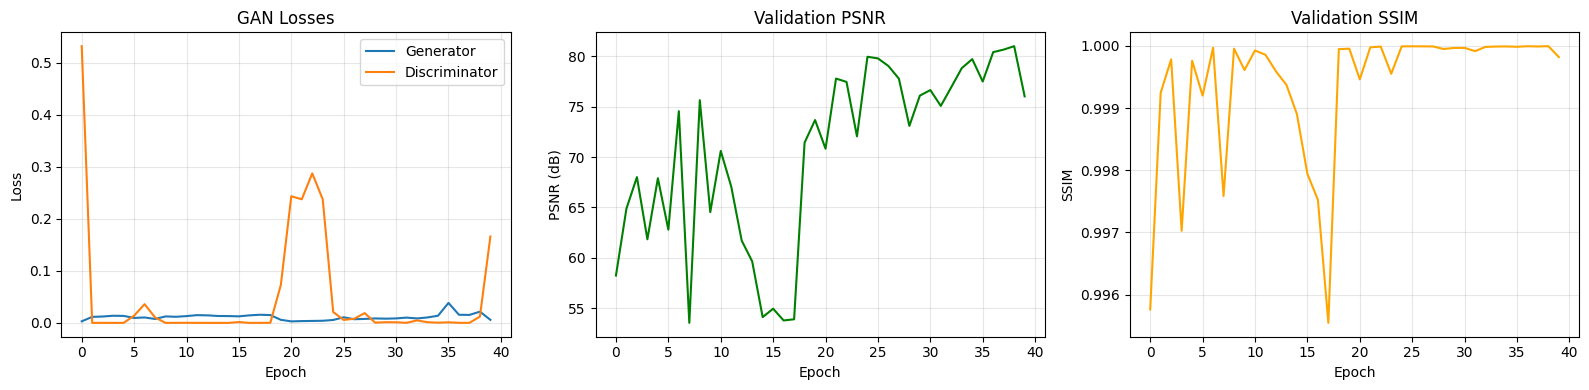

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['g_loss'], label='Generator')
axes[0].plot(history['d_loss'], label='Discriminator')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('GAN Losses'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_psnr'], color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Validation PSNR'); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_ssim'], color='orange')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('SSIM')
axes[2].set_title('Validation SSIM'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation on Test Set

In [26]:
# ============================================================
# Quantitative evaluation
# ============================================================
generator.eval()
test_psnr, test_ssim, test_energy_ratio = [], [], []
all_sr, all_hr, all_lr = [], [], []

with torch.no_grad():
    for lr_imgs, hr_imgs in test_loader:
        sr = generator(lr_imgs.to(device)).cpu().numpy()
        hr_np = hr_imgs.numpy()
        lr_np = lr_imgs.numpy()

        for i in range(len(sr)):
            sr_i = np.clip(sr[i], -1, 1)
            hr_i = hr_np[i]

            test_psnr.append(compute_psnr(hr_i, sr_i, data_range=2.0))
            test_ssim.append(compute_ssim(hr_i, sr_i, data_range=2.0, channel_axis=0))

            sr_energy = sr_i.sum()
            hr_energy = hr_i.sum()
            if abs(hr_energy) > 1e-6:
                test_energy_ratio.append(sr_energy / hr_energy)

            all_sr.append(sr_i)
            all_hr.append(hr_i)
            all_lr.append(lr_np[i])

print('=' * 55)
print('TEST SET RESULTS')
print('=' * 55)
print(f'PSNR:          {np.mean(test_psnr):.2f} ± {np.std(test_psnr):.2f} dB')
print(f'SSIM:          {np.mean(test_ssim):.4f} ± {np.std(test_ssim):.4f}')
print(f'Energy ratio:  {np.mean(test_energy_ratio):.4f} ± {np.std(test_energy_ratio):.4f}')
print(f'  (1.0 = perfect energy conservation)')

TEST SET RESULTS
PSNR:          76.02 ± 0.08 dB
SSIM:          0.9998 ± 0.0000
Energy ratio:  -311.8722 ± 79.2640
  (1.0 = perfect energy conservation)


In [27]:
# ============================================================
# Baseline: bicubic interpolation
# ============================================================
baseline_psnr, baseline_ssim = [], []
for i in range(len(all_lr)):
    lr_t = torch.from_numpy(all_lr[i]).unsqueeze(0)
    bicubic = F.interpolate(lr_t, size=125, mode='bicubic', align_corners=False).squeeze(0).numpy()
    hr_i = all_hr[i]
    baseline_psnr.append(compute_psnr(hr_i, bicubic, data_range=2.0))
    baseline_ssim.append(compute_ssim(hr_i, bicubic, data_range=2.0, channel_axis=0))

print('\n--- Comparison with Bicubic Baseline ---')
print(f'{"Metric":<14} {"Bicubic":<18} {"ESRGAN":<18} {"Improvement"}')
print('-' * 62)
p_imp = np.mean(test_psnr) - np.mean(baseline_psnr)
s_imp = np.mean(test_ssim) - np.mean(baseline_ssim)
print(f'{"PSNR (dB)":<14} {np.mean(baseline_psnr):<18.2f} {np.mean(test_psnr):<18.2f} +{p_imp:.2f}')
print(f'{"SSIM":<14} {np.mean(baseline_ssim):<18.4f} {np.mean(test_ssim):<18.4f} +{s_imp:.4f}')


--- Comparison with Bicubic Baseline ---
Metric         Bicubic            ESRGAN             Improvement
--------------------------------------------------------------
PSNR (dB)      100.38             76.02              +-24.36
SSIM           1.0000             0.9998             +-0.0002


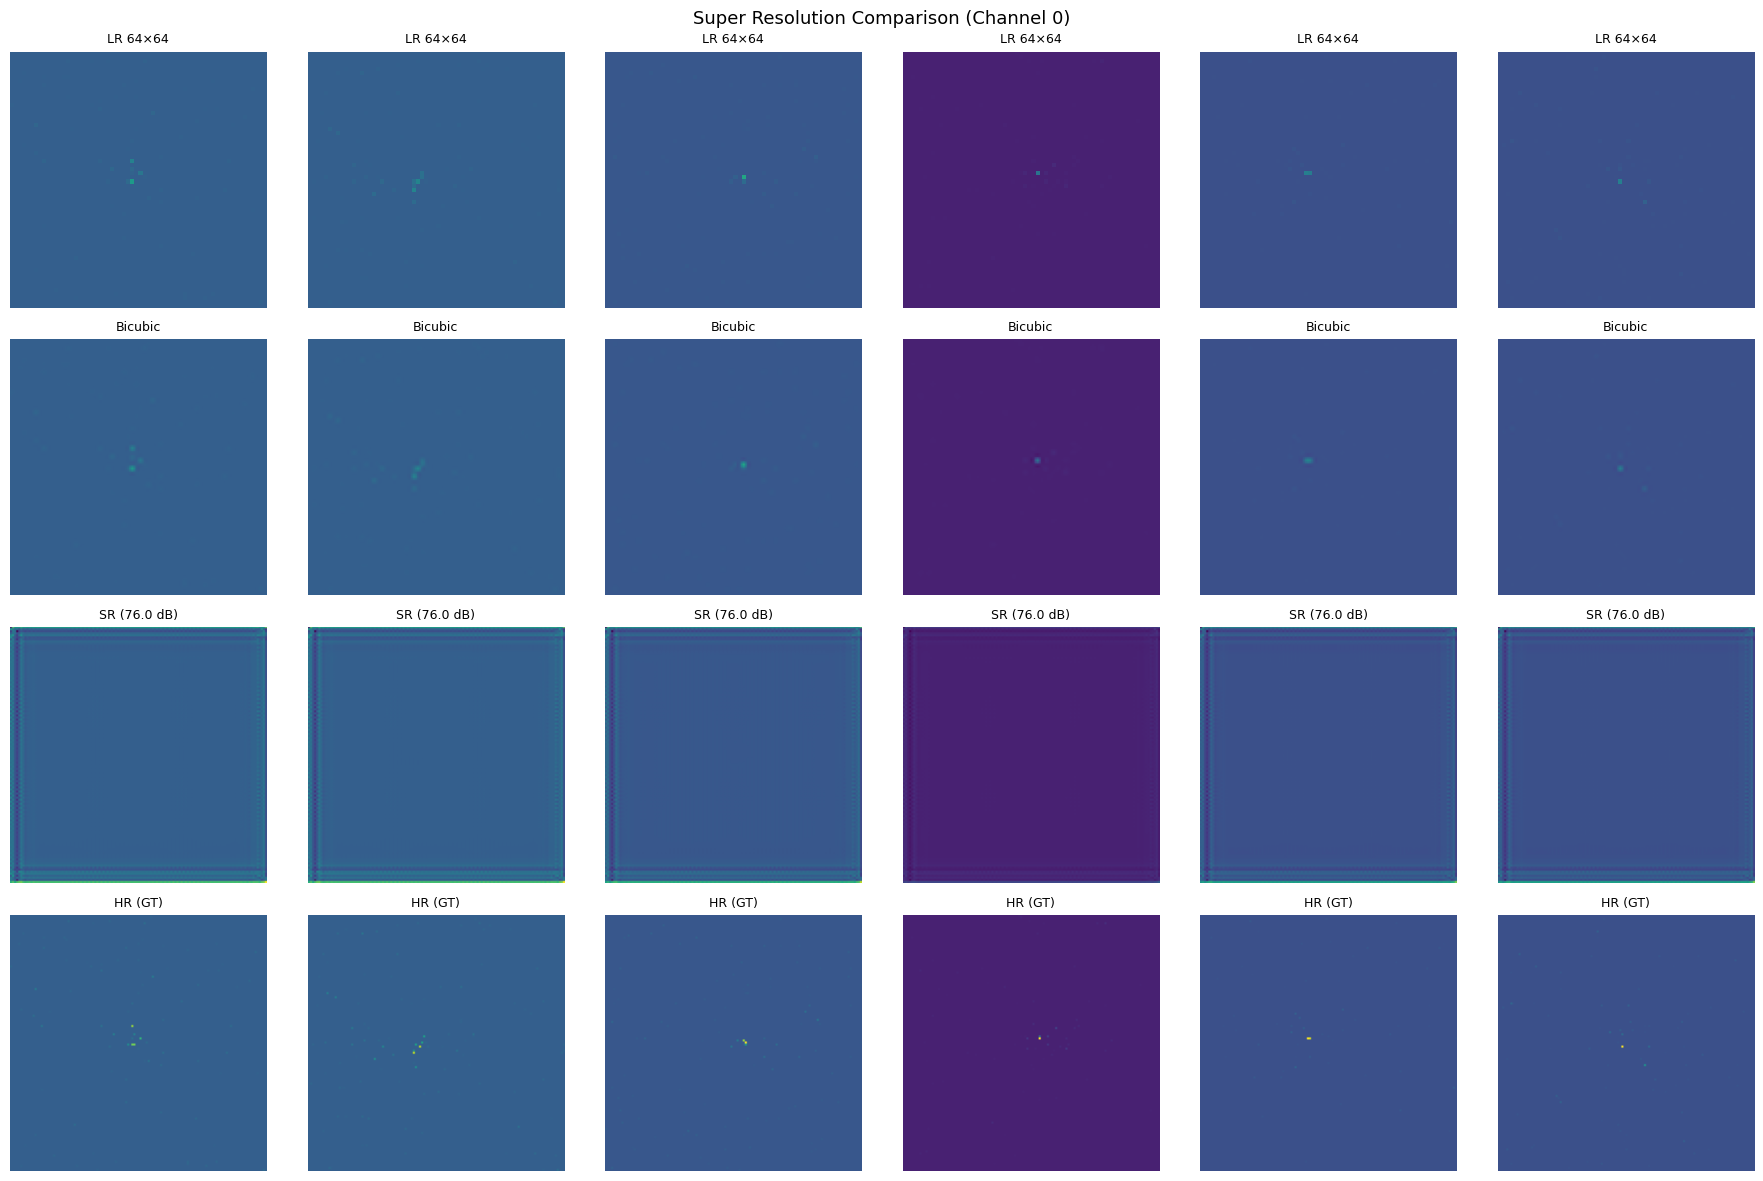

In [28]:
# ============================================================
# Visual comparison: LR → Bicubic → SR → HR
# ============================================================
n_show = 6
fig, axes = plt.subplots(4, n_show, figsize=(18, 12))
sample_idx = np.random.RandomState(0).choice(len(all_sr), n_show, replace=False)

for col, idx in enumerate(sample_idx):
    lr_vis = all_lr[idx][0]
    sr_vis = all_sr[idx][0]
    hr_vis = all_hr[idx][0]

    # Bicubic baseline
    bic = F.interpolate(torch.from_numpy(all_lr[idx]).unsqueeze(0),
                        size=125, mode='bicubic', align_corners=False)
    bic_vis = bic.squeeze(0).numpy()[0]

    vmin = min(lr_vis.min(), sr_vis.min(), hr_vis.min(), bic_vis.min())
    vmax = max(lr_vis.max(), sr_vis.max(), hr_vis.max(), bic_vis.max())

    axes[0, col].imshow(lr_vis, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, col].set_title('LR 64×64', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(bic_vis, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, col].set_title('Bicubic', fontsize=9)
    axes[1, col].axis('off')

    axes[2, col].imshow(sr_vis, cmap='viridis', vmin=vmin, vmax=vmax)
    p = compute_psnr(all_hr[idx], all_sr[idx], data_range=2.0)
    axes[2, col].set_title(f'SR ({p:.1f} dB)', fontsize=9)
    axes[2, col].axis('off')

    axes[3, col].imshow(hr_vis, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[3, col].set_title('HR (GT)', fontsize=9)
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('LR Input', fontsize=11)
axes[1, 0].set_ylabel('Bicubic', fontsize=11)
axes[2, 0].set_ylabel('ESRGAN (Ours)', fontsize=11)
axes[3, 0].set_ylabel('HR Ground Truth', fontsize=11)

plt.suptitle('Super Resolution Comparison (Channel 0)', fontsize=13)
plt.tight_layout()
plt.savefig('sr_visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

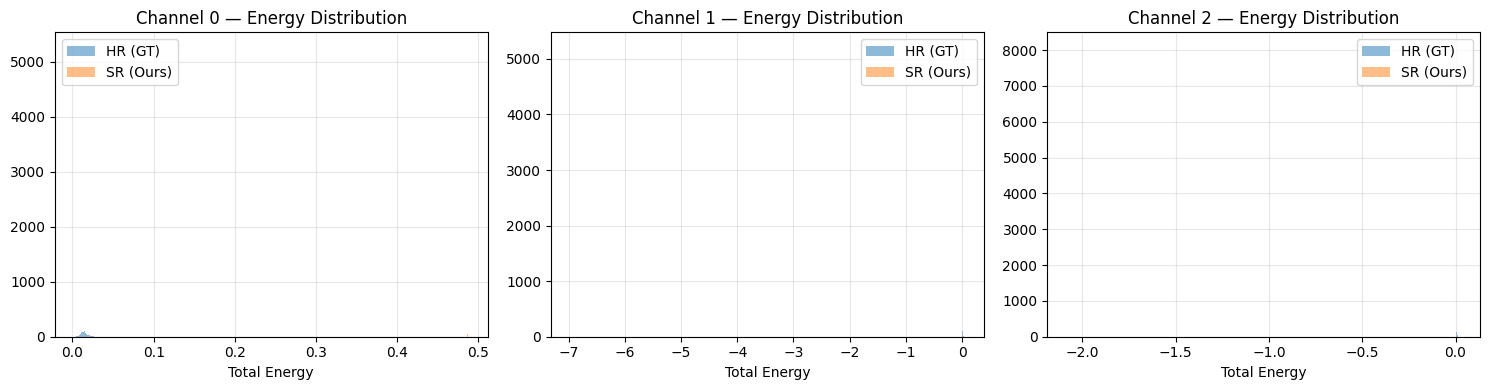

In [29]:
# ============================================================
# Per-channel energy distribution comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ch_names = ['Channel 0', 'Channel 1', 'Channel 2']

for ch in range(3):
    sr_ch = np.array([img[ch].sum() for img in all_sr])
    hr_ch = np.array([img[ch].sum() for img in all_hr])

    axes[ch].hist(hr_ch, bins=50, alpha=0.5, label='HR (GT)', density=True)
    axes[ch].hist(sr_ch, bins=50, alpha=0.5, label='SR (Ours)', density=True)
    axes[ch].set_title(f'{ch_names[ch]} — Energy Distribution')
    axes[ch].set_xlabel('Total Energy')
    axes[ch].legend()
    axes[ch].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('energy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Save all figures to Drive
import shutil
for fig_name in ['lr_hr_comparison.png', 'training_curves.png', 'sr_visual_comparison.png', 'energy_distribution.png']:
    try:
        shutil.copy(fig_name, '/content/drive/MyDrive/task2b dataset/')
        print(f'Saved {fig_name}')
    except:
        print(f'{fig_name} not found')

Saved lr_hr_comparison.png
Saved training_curves.png
Saved sr_visual_comparison.png
Saved energy_distribution.png


## 9. Discussion

### Model Selection

**Why ESRGAN over alternatives:**
- **SRCNN / VDSR**: Too shallow — limited capacity for the complex 64→125 upsampling task.
- **SRGAN**: Uses standard ResBlocks with Batch Normalization, which can introduce artifacts. ESRGAN's RRDB blocks (without BN) are more stable.
- **SwinIR / HAT**: Transformer-based methods could yield better results but require significantly more compute and data. For proof-of-concept, ESRGAN provides a strong baseline.

### Upsampling Strategy

The non-integer scale factor (64→125, ~1.95×) posed a design challenge. I used PixelShuffle for 2× upsampling (64→128) followed by learned bilinear interpolation (128→125). This avoids information loss from direct non-integer interpolation while keeping the architecture clean. An alternative approach would be to pad LR to 63×63 and use 2× PixelShuffle to get 126×126, then crop — but this wastes information at boundaries.

### Optimization Strategy

- **Two-phase training**: Pre-training with L1 loss only stabilizes the generator before introducing adversarial training.
- **Relativistic average discriminator**: Provides more informative gradients than standard GAN.
- **Loss weighting**: Pixel loss is dominant (λ=1.0) because physics data demands accurate energy reconstruction. Perceptual and adversarial losses add high-frequency details without distorting physical quantities.

### Considerations for Physics Data

- **Energy conservation**: The energy ratio metric (SR_energy / HR_energy) should approach 1.0. Deviation indicates the model is creating or destroying energy, which is physically meaningless.
- **Negative values**: The raw data contains negative values (noise from detector electronics). The model must learn to preserve these rather than clipping to zero.
- **VGG features on non-natural images**: The perceptual loss uses features learned from ImageNet. For calorimeter data, these features may not capture the most relevant physics patterns. A domain-specific feature extractor trained on physics data could improve results.

### Potential Improvements for the GSoC Project

As noted in the project description, the full GSoC project should explore modern architectures:
- **Visual Autoregression (VAR)**: Autoregressive generation of HR patches conditioned on LR.
- **Joint Embedding Predictive Architectures (JEPA)**: Self-supervised pretraining on unlabeled calorimeter data.
- **Diffusion-based SR**: Conditional diffusion models that can model the full HR distribution, as demonstrated by SuperCalo (arXiv:2404.02905).
- **Physics-informed loss**: Adding energy conservation constraints directly into the training objective.
- **Graph-based SR**: Following the approach of arXiv:2409.16052, treating calorimeter hits as graphs rather than images could better capture the sparse, irregular nature of the data.